<a href="https://colab.research.google.com/github/KyleFranzR/CPE-313/blob/main/Rodriguez_Hands-on-Activity-9.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE313
Code Title: | Advanced Machine Learning and Deep Learning
2nd Semester | AY 2025-2026
<u>**HOA 9.1** | **Saving & Loading Models**
**Name** | De Guzman, Rodriguez
**Section** | CPE31S3
**Date Performed**: | 2026-04-12
**Date Submitted**: | 2026-04-12
**Instructor**: | Engr. Neal Barton James Matira
<hr>

In [ ]:
import numpy
import os
import pandas as pd
import matplotlib.pyplot as plt

# Part 1

### The problem

> Heart Disease is the number 1 cause of death globally, which is estimated to be the cause of approximately 9 million people annually.
https://www.who.int/data/gho/data/themes/mortality-and-global-health-estimates

## The dataset
> https://www.kaggle.com/datasets/vishardmehta/heart-risk-progression-dataset

> The dataset stores the records of several patients' cardiovascular health checkups. It is designed for predicting heart disease risks and we will use it to help advance clinical diagnosis and early treatment. We will use the dataset for both classification and regression models.

In [ ]:
heart = pd.read_csv('/content/cardiovascular_risk_dataset.csv')
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        5500 non-null   int64  
 1   age                               5500 non-null   int64  
 2   bmi                               5500 non-null   float64
 3   systolic_bp                       5500 non-null   int64  
 4   diastolic_bp                      5500 non-null   int64  
 5   cholesterol_mg_dl                 5500 non-null   int64  
 6   resting_heart_rate                5500 non-null   int64  
 7   smoking_status                    5500 non-null   object 
 8   daily_steps                       5500 non-null   int64  
 9   stress_level                      5500 non-null   int64  
 10  physical_activity_hours_per_week  5500 non-null   float64
 11  sleep_hours                       5500 non-null   float64
 12  family

In [ ]:
# check some object columns

print(heart.smoking_status.unique())
print(heart.family_history_heart_disease.unique())
print(heart.risk_category.unique())

['Never' 'Current' 'Former']
['No' 'Yes']
['Medium' 'High' 'Low']


In [ ]:
# let's one-hot the first two columns

cols = ['smoking_status', 'family_history_heart_disease']
heart_hot = pd.get_dummies(heart, columns=cols, dtype= int)

In [ ]:
# Then label the risk category

risk = {'Low': 0, 'Medium': 1, 'High': 2}
heart_hot.risk_category = heart_hot.risk_category.map(risk)

In [ ]:
# then let's drop the patient_ID

heart_hot = heart_hot.drop('Patient_ID', axis=1)

In [ ]:
heart_hot.head()

,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category,smoking_status_Current,smoking_status_Former,smoking_status_Never,family_history_heart_disease_No,family_history_heart_disease_Yes
0,62,25.0,142,93,247,72,11565,3,5.6,8.2,7,0.7,28.1,1,0,0,1,1,0
1,54,29.7,158,101,254,74,4036,8,0.5,6.7,5,4.5,63.0,2,1,0,0,1,0
2,46,36.2,170,113,276,80,3043,9,0.4,4.0,1,20.8,73.1,2,1,0,0,1,0
3,48,30.4,153,98,230,73,5604,5,0.6,8.0,4,8.5,39.5,1,0,1,0,1,0
4,46,25.3,139,87,206,69,7464,1,2.0,6.1,5,3.6,29.3,1,1,0,0,1,0


## Model Training

### Classification Model

> For classification, we want to use the risk_category column as the classes to predict

In [ ]:
# the risk_category is in the 13th column

heart_hot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               5500 non-null   int64  
 1   bmi                               5500 non-null   float64
 2   systolic_bp                       5500 non-null   int64  
 3   diastolic_bp                      5500 non-null   int64  
 4   cholesterol_mg_dl                 5500 non-null   int64  
 5   resting_heart_rate                5500 non-null   int64  
 6   daily_steps                       5500 non-null   int64  
 7   stress_level                      5500 non-null   int64  
 8   physical_activity_hours_per_week  5500 non-null   float64
 9   sleep_hours                       5500 non-null   float64
 10  diet_quality_score                5500 non-null   int64  
 11  alcohol_units_per_week            5500 non-null   float64
 12  heart_

In [ ]:
# split into input (X) and output (Y) variables

X = heart_hot.drop('risk_category', axis=1).values
Y = heart_hot.risk_category.values

#### Initial Training

In [ ]:
from tensorflow.keras.models import Sequential, model_from_json
from tensorflow.keras.layers import Input, Dense

In [ ]:
numpy.random.seed(7)

In [ ]:
# create model
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(X.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

# Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Fit the model
model.fit(X, Y, epochs=150, batch_size=10, verbose=0)

In [ ]:
# evaluate the model
scores = model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

compile_metrics: 95.51%


#### Adding More Hidden Layers

In [ ]:
model_classification = Sequential()
model_classification.add(Input(shape=(X.shape[1],)))
model_classification.add(Dense(32, activation='relu'))
model_classification.add(Dense(16, activation='relu'))
model_classification.add(Dense(3, activation='softmax'))

model_classification.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model_classification.fit(X, Y, epochs=150, batch_size=10, verbose=0)

scores = model_classification.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model_classification.metrics_names[1], scores[1]*100))

compile_metrics: 96.96%


> The modified model only improved by a small margin

### Regression Model

> For regression, we want to use the heart_disease_risk_score in the 12th column as the target for our regression

In [ ]:
X = heart_hot.drop('heart_disease_risk_score', axis=1).values
Y = heart_hot.heart_disease_risk_score.values

#### Initial Training

In [ ]:
model_reg = Sequential()
model_reg.add(Dense(16, activation='relu', input_shape=(X.shape[1],)))
model_reg.add(Dense(8, activation='relu'))
model_reg.add(Dense(1))

model_reg.compile(loss='mse', optimizer='adam', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model_reg.fit(X, Y, epochs=150, batch_size=10, verbose=0)

In [ ]:
scores = model_reg.evaluate(X, Y, verbose=0)
print(f"Mean Squared Error: {scores[0]}")
print(f"Mean Absolute Error: {scores[1]}")

Mean Squared Error: 13.206718444824219
Mean Absolute Error: 2.887195110321045


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


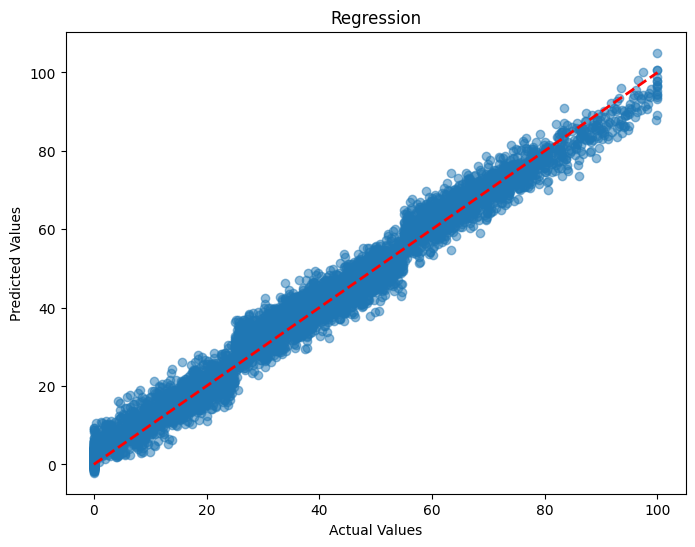

In [ ]:
predictions = model_reg.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(Y, predictions, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Regression')
plt.show()

#### Improving the model

In [ ]:
# Standarize the dataset
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)

##### Smaller Network

In [ ]:
model_reg_small = Sequential()
model_reg_small.add(Input(shape=(X.shape[1],)))
model_reg_small.add(Dense(16, activation='relu', ))
model_reg_small.add(Dense(8, activation='relu'))
model_reg_small.add(Dense(1))

model_reg_small.compile(loss='mse', optimizer='adam', metrics=['mae'])

In [ ]:
history = model_reg_small.fit(X_scaled, Y, epochs=150, batch_size=10, verbose=0)

In [ ]:
scores = model_reg_small.evaluate(X_scaled, Y, verbose=0)
print(f"Mean Squared Error: {scores[0]}")
print(f"Mean Absolute Error: {scores[1]}")

Mean Squared Error: 6.896219253540039
Mean Absolute Error: 2.0212759971618652


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


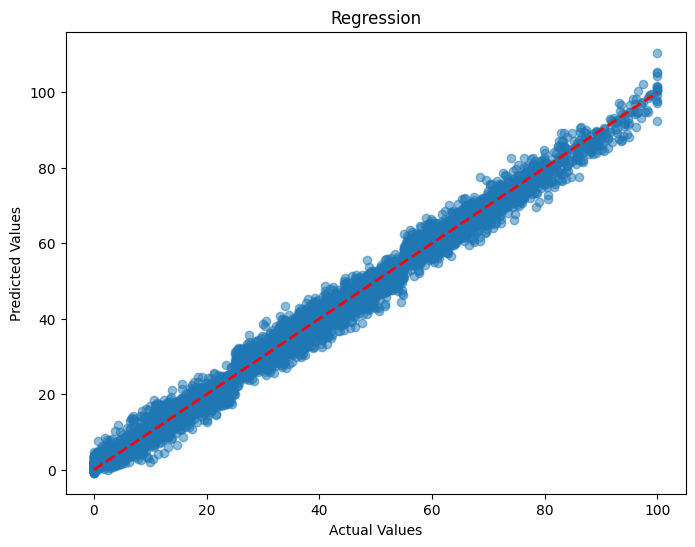

In [ ]:
predictions = model_reg_small.predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(Y, predictions, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Regression')
plt.show()

##### Larger Network

In [ ]:
model_reg_large = Sequential()
model_reg_large.add(Input(shape=(X.shape[1],)))
model_reg_large.add(Dense(64, activation='relu', ))
model_reg_large.add(Dense(32, activation='relu', ))
model_reg_large.add(Dense(16, activation='relu', ))
model_reg_large.add(Dense(8, activation='relu'))
model_reg_large.add(Dense(1))

model_reg_large.compile(loss='mse', optimizer='adam', metrics=['mae'])

In [ ]:
history = model_reg_large.fit(X_scaled, Y, epochs=150, batch_size=10, verbose=0)

In [ ]:
scores = model_reg_large.evaluate(X_scaled, Y, verbose=0)
print(f"Mean Squared Error: {scores[0]}")
print(f"Mean Absolute Error: {scores[1]}")

Mean Squared Error: 5.282341003417969
Mean Absolute Error: 1.746330976486206


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


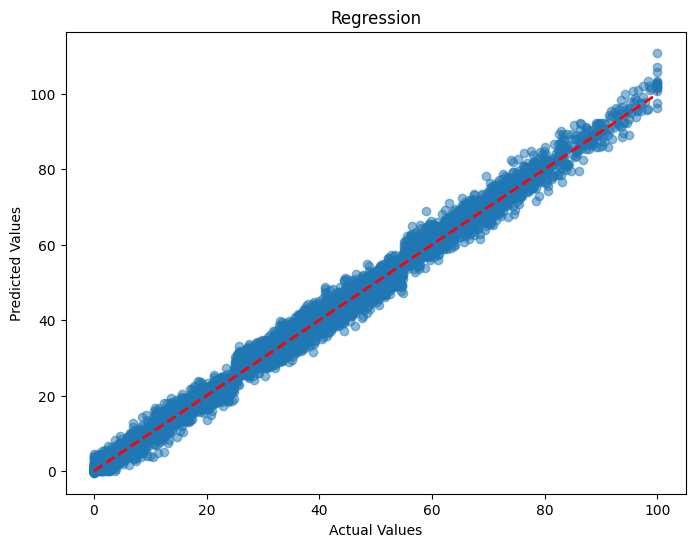

In [ ]:
predictions = model_reg_large.predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(Y, predictions, alpha=0.5)
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Regression')
plt.show()

> Scaling the dataset significantly reduced the value of the MSE and MAE. However, Increasing the network only reduced the MAE by .20 which is minimal.

# Part 2

## Save a model in H5 format

In [ ]:
!pip install h5py --quiet

In [ ]:
# for this part, we will save the two models we made above

model_classification.save_weights('heart_risk_classification_model.weights.h5')
model_reg_large.save_weights('heart_risk_regression_model.weights.h5')

## Save and Load the model in a JSON format

### Saving

In [ ]:
# for classification

model_classification_json = model_classification.to_json()
with open("model_classification.json", "w") as json_file: json_file.write(model_classification_json)

In [ ]:
# for regression

model_regression_json = model_reg_large.to_json()
with open("model_regression.json", "w") as json_file: json_file.write(model_regression_json)

### Loading

In [ ]:
# for classification

json_file = open('model_classification.json', 'r')
loaded_classification = json_file.read()
json_file.close()

heart_cls_model = model_from_json(loaded_classification)
heart_cls_model.load_weights("/content/heart_risk_classification_model.weights.h5")
heart_cls_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

score = heart_cls_model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (heart_cls_model.metrics_names[1], score[1]*100))

compile_metrics: 97.40%


In [ ]:
# for regression

json_file = open('model_regression.json', 'r')
loaded_regression = json_file.read()
json_file.close()

heart_reg_model = model_from_json(loaded_regression)
heart_reg_model.load_weights("/content/heart_risk_regression_model.weights.h5")
heart_reg_model.compile(loss='mse', optimizer='adam', metrics=['mae'])

scores = heart_reg_model.evaluate(X_scaled, Y, verbose=0)
print(f"Mean Squared Error: {scores[0]}")
print(f"Mean Absolute Error: {scores[1]}")

Mean Squared Error: 5.783087730407715
Mean Absolute Error: 1.8479936122894287


## Save and Load the model in a YAML format

### Saving

In [ ]:
# for classification

model_classification_yaml = model_classification.to_json()
with open("model_classification.yaml", "w") as yaml_file: yaml_file.write(model_classification_yaml)

In [ ]:
# for regression

model_regression_yaml = model_reg_large.to_json()
with open("model_regression.yaml", "w") as yaml_file: yaml_file.write(model_regression_yaml)

### Loading

In [ ]:
# for classification

yaml_file = open('model_classification.yaml', 'r')
loaded_classification = yaml_file.read()
yaml_file.close()

heart_cls_model = model_from_json(loaded_classification)
heart_cls_model.load_weights("/content/heart_risk_classification_model.weights.h5")
heart_cls_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

score = heart_cls_model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (heart_cls_model.metrics_names[1], score[1]*100))

compile_metrics: 96.96%


In [ ]:
# for regression

yaml_file = open('model_regression.yaml', 'r')
loaded_regression = yaml_file.read()
yaml_file.close()

heart_reg_model = model_from_json(loaded_regression)
heart_reg_model.load_weights("/content/heart_risk_regression_model.weights.h5")
heart_reg_model.compile(loss='mse', optimizer='adam', metrics=['mae'])

scores = heart_reg_model.evaluate(X_scaled, Y, verbose=0)
print(f"Mean Squared Error: {scores[0]}")
print(f"Mean Absolute Error: {scores[1]}")

Mean Squared Error: 5.282341003417969
Mean Absolute Error: 1.746330976486206


For the next parts, We are only going to do one model, which is the classification model because it is tedious.

## Using Checkpoint

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
# Recall the classification model:

model_cls = Sequential()
model_cls.add(Input(shape=(X.shape[1],)))
model_cls.add(Dense(32, activation='relu'))
model_cls.add(Dense(16, activation='relu'))
model_cls.add(Dense(3, activation='softmax'))

model_cls.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

### Checkpoint Improvements

In [ ]:
# This creates multiple files for every time the performance of the model improves

folder = "heart_cls_model_checkpoints"
if not os.path.exists(folder): os.makedirs(folder)
filepath = os.path.join(folder, "heart_cls_model_{epoch:02d}_{val_accuracy:.4f}.weights.h5")

checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode='max'
)

In [ ]:
model_cls.fit(X, Y, validation_split=0.2, epochs=150, batch_size=10, verbose=0, callbacks=[checkpoint])

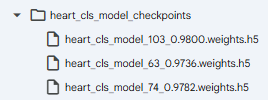

### Checkpoint the best

In [ ]:
filepath = os.path.join(folder, "heart_cls_model_best.weights.h5")

checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=0,
    save_best_only=True,
    save_weights_only=True,
    mode='max'
)

In [ ]:
# reset the model before fitting

model_cls.fit(X, Y, validation_split=0.2, epochs=150, batch_size=10, verbose=0, callbacks=[checkpoint])

### Testing the checkpoints

In [ ]:
# load the skeleton first

with open('model_classification.yaml', 'r') as yaml_file:
    heart_cls_model = model_from_json(yaml_file.read())

In [ ]:
# loading the highest weight improvement

heart_cls_model.load_weights("/content/heart_cls_model_checkpoints/heart_cls_model_126_0.9809.weights.h5")
heart_cls_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

score = heart_cls_model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (heart_cls_model.metrics_names[1], score[1]*100))

compile_metrics: 97.76%


In [ ]:
# loading the best weight

heart_cls_model.load_weights("/content/heart_cls_model_checkpoints/heart_cls_model_best.weights.h5")
heart_cls_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

score = heart_cls_model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (heart_cls_model.metrics_names[1], score[1]*100))

compile_metrics: 97.35%


## Loading the Highest Checkpoint

In [ ]:
heart_cls_model.load_weights("/content/heart_cls_model_checkpoints/heart_cls_model_126_0.9809.weights.h5")
heart_cls_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## Visualizing Training History

In [ ]:
# We can visualize the history if we store the fitting in a variable
# Sad that we forgot to do it above, so we reset the model and fit again
# This time showing how we can save the history

model_cls = Sequential()
model_cls.add(Input(shape=(X.shape[1],)))
model_cls.add(Dense(32, activation='relu'))
model_cls.add(Dense(16, activation='relu'))
model_cls.add(Dense(3, activation='softmax'))

model_cls.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model_cls.fit(X, Y, validation_split=0.2, epochs=150, batch_size=10, verbose=0, callbacks=[checkpoint])

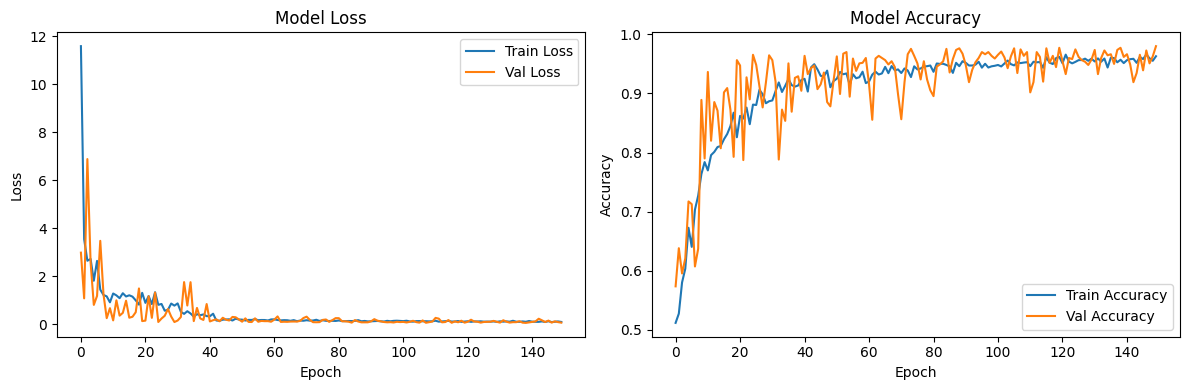

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()


ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

> Looking at the graph, we can see that the model learns fast and there was no overfitting the occured.

## Applying Dropout Regularization

Even though no overfitting occured, let's try adding dropouts

In [ ]:
from tensorflow.keras.layers import Dropout

### Dropout on Visible Layer

In [ ]:
model_cls = Sequential()
model_cls.add(Input(shape=(X.shape[1],)))
model_cls.add(Dropout(0.2))

### Dropout on Hidden Layer

In [ ]:
model_cls.add(Dense(32, activation='relu'))
model_cls.add(Dropout(0.2))
model_cls.add(Dense(16, activation='relu'))
model_cls.add(Dropout(0.2))
model_cls.add(Dense(3, activation='softmax'))

## Applying Learning Rate Schedule

> We can apply this to speed up the learning of the model, and decrease as the epoch goes by.

### Time-based Learning Rate Schedule

> I think this is already present in the built in optimizer of tensorflow, but the way this works if the learning rate decays as the epoch increases.

In [ ]:
from tensorflow.keras.optimizers import Adam

epochs = 150
lr = 0.01
decay_rate = 0.01 / 150

opti = Adam(learning_rate=lr, decay=decay_rate)

model_cls.compile(loss='sparse_categorical_crossentropy', optimizer=opti, metrics=['accuracy'])

### Drop-based Learning Rate Schedule

> This is the same with Time-based but we lower the learning rate by a factor for every epochs

In [ ]:
import math
from tensorflow.keras.callbacks import LearningRateScheduler

def step_decay(epoch):
	initial_lrate = 0.1
	drop = 0.5
	epochs_drop = 20.0
	lrate = initial_lrate * math.pow(drop, math.floor((1+epoch)/epochs_drop))
	return lrate

lr_scheduler = LearningRateScheduler(step_decay)

## The Final Model

In [ ]:
# We are going to use drop-based learning rate,
# so we will recompile the model

model_cls.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
history = model_cls.fit(X, Y, validation_split=0.2, epochs=150, batch_size=10, verbose=0, callbacks=[lr_scheduler])

In [ ]:
# evaluate the model
scores = model_cls.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (model_cls.metrics_names[1], scores[1]*100))

compile_metrics: 72.60%


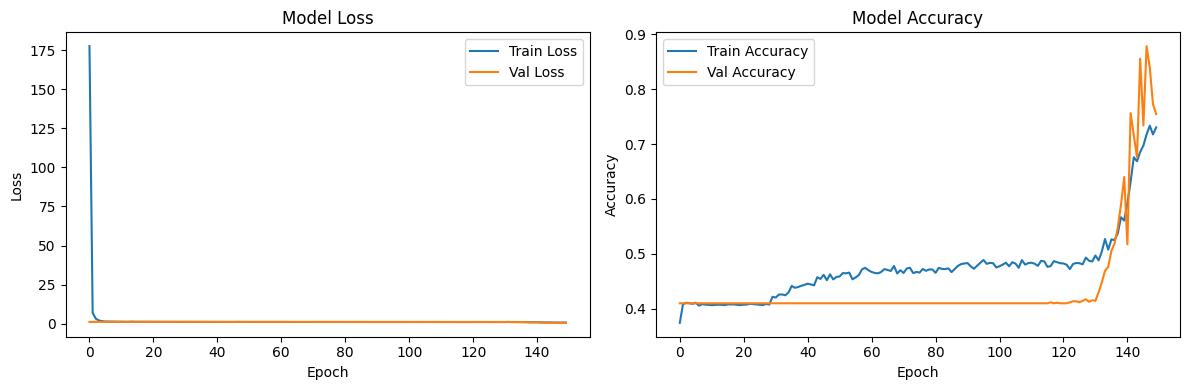

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()


ax2.plot(history.history['accuracy'], label='Train Accuracy')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

> We thought that our dataset and model is a special case because the performance of the model significantly dropped after using dropouts and learning rate scheduler. So, it is safe to say that the best model is the preview ones that we saved.

In [ ]:
# Loading the best final model:

yaml_file = open('model_classification.yaml', 'r')
loaded_classification = yaml_file.read()
yaml_file.close()

final_model = model_from_json(loaded_classification)
final_model.load_weights("/content/heart_cls_model_checkpoints/heart_cls_model_126_0.9809.weights.h5")
final_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

score = heart_cls_model.evaluate(X, Y, verbose=0)
print("%s: %.2f%%" % (heart_cls_model.metrics_names[1], score[1]*100))

compile_metrics: 97.76%


# Conclusion

> ***In this activity, we were able to demonstrate how to save a model, save a checkpoint, and how we can apply modifications to the architecture such as dropouts and learning rate scheduler. In saving a model, the way that was demonstrated in this activity is to save the weights and the architecture of the model separately. For the weights, we either we used h5, and for the architecture we exported to either json or yaml files. This is nice to know because the saving options that we already know is to save the model in a single file of either .keras, or .pt, or .pkl. Overall, we were able to finally understand the important of saving our model, especially the checkpoints, for either deployment or as a backup in case a wrong decision happened.***